# Recovery for NoInhibition model

Goal of this notebook:

1. Define a direct measurement model for:
   - $p_{\text{intention},A}$
   - $p_{\text{intention},B}$
   - $p_{\text{recall},X}$
   - $p_{\text{recall},Y}$

2. Use no-inhibition mDMC logic as basis for predicted accuracies.

3. Run simulation-based recovery using the real filtered denominators from the final fitting sample.

4. Summarize recovery quality using:
   - scatterplots of true vs recovered values
   - correlation
   - bias
   - RMSE

5. Fit the real sample only if recovery looks acceptable.

6. Compare observed vs predicted AX/AY/BX/BY accuracies in the real data.

This notebook does **not** yet fit the full process model with alpha / alphaAX / delta_t / lambda.
It focuses only on recoverability of the measurement-level probabilities.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import binom

## Load fitting sample

In [12]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

fit_path = project_root / "data" / "AXCPT_12yr_fitting_sample.csv"
fit_df = pd.read_csv(fit_path)

print("Loaded:", fit_path)
print("Shape:", fit_df.shape)
fit_df.head()

Loaded: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv
Shape: (129, 41)


,ID,Completed_AX_CPT_12yr,acc_rej_12yr,AX_CPT_Notes_12yr,Mean_RT_12yr,Std_pop_12yr,Std_3_12yr,Lo_Std_12yr,Hi_Std_12yr,AX_Count_12yr,...,PBSI_RT_12yr,PBSI_SUM_12yr,dprime_context_12yr,A_Cue_Bias_12yr,A_Cue_Bias_Check,AY_False_Alarm,has_all_counts,has_all_acc_counts,model_usable,has_any_core
0,6018.0,1.0,1.0,NaN,450.33,127.57,382.71,67.62,833.04,105.0,...,0.174679,0.362179,0.498652,0.342373,0.342373,0.642857,True,True,True,True
1,6029.0,1.0,1.0,NaN,556.35,177.39,532.17,24.18,1088.52,105.0,...,0.318952,0.718952,3.119669,0.431398,0.431398,0.214286,True,True,True,True
2,6038.0,1.0,1.0,NaN,469.03,162.78,488.34,-19.31,957.37,105.0,...,0.197544,0.165286,1.382736,-0.125262,-0.125262,0.200000,True,True,True,True
3,6040.0,1.0,1.0,NaN,409.18,160.49,481.47,-72.29,890.65,105.0,...,0.285968,1.013241,2.562589,0.657425,0.657425,0.600000,True,True,True,True
4,6043.0,1.0,1.0,NaN,427.63,122.07,366.21,61.42,793.84,105.0,...,0.130951,0.276714,1.734510,0.603612,0.603612,0.461538,True,True,True,True


## Define trial-type columns and design constants

Use the fitting sample's filtered denominators and correct counts.

Fixed settings:
- trial-type proportions to the intended design: 70/10/10/10
- load = 1 (assuming standard single A-cue version)
- recall accuracy scaling parameter `m`
- slip probability `p_slip`

These fixed settings should be revisited later in sensitivity analyses if needed.

In [38]:
TRIAL_TYPES = ["AX", "AY", "BX", "BY"]

count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr",
]

acc_count_cols = [
    "AX_Acc_Count_12yr",
    "AY_Acc_Count_12yr",
    "BX_Acc_Count_12yr",
    "BY_Acc_Count_12yr",
]

acc_rate_cols = [
    "AX_Acc_12yr",
    "AY_Acc_12yr",
    "BX_Acc_12yr",
    "BY_Acc_12yr",
]

p_cue_probe = np.array([0.70, 0.10, 0.10, 0.10], dtype=float)

# provisional fixed assumptions for measurement-model recovery
load = 1
m = 1

print("Using p_cue_probe =", p_cue_probe)
print("Using load =", load, "m =", m)

Using p_cue_probe = [0.7 0.1 0.1 0.1]
Using load = 1 m = 1


In [39]:
p_slip = 1 - fit_df["BY_Acc_12yr"].mean()
print("Sample-specific slip estimate:", p_slip)

Sample-specific slip estimate: 0.15375528863900956


# 4-parameter No-inhibition Recovery

## Helpers

- *habit* accuracy by trial type
- *proactive* accuracy by trial type
- *recall* accuracy by trial type
- predicted trial-type accuracies given:
  - $p_{\text{intention},A}$
  - $p_{\text{intention},B}$
  - $p_{\text{recall},X}$
  - $p_{\text{recall},Y}$

> Intention depends on cue (A vs B); recall depends on probe (X vs Y)

In [40]:
def compute_component_accuracies(p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    Returns habit, proactive, and recall accuracies for trial types
    [AX, AY, BX, BY].
    """
    pAX, pAY, pBX, pBY = p_cue_probe

    # Habitual accuracy
    # For X probes, habit follows the marginal AX/BX frequency under X
    # For Y probes, habitual responding is effectively "not AX"
    p_correct_habit = np.array([
        pAX / (pAX + pBX),   # AX
        1.0,                 # AY
        pBX / (pAX + pBX),   # BX
        1.0                  # BY
    ], dtype=float)

    # Proactive accuracy under no-inhibition logic
    proactive_base = np.array([
        pAX / (pAX + pAY),         # AX
        1.0 - pAX / (pAX + pAY),   # AY
        1.0,                       # BX
        1.0                        # BY
    ], dtype=float)

    proactive_base = proactive_base * (1.0 - lambda_ * (load - 1))

    # Recall accuracy
    recall_base = np.full(4, m * (1.0 - lambda_ * (load - 1)), dtype=float)

    # Apply slip
    def apply_slip(p):
        return p * (1 - p_slip) + (1 - p) * p_slip

    p_correct_habit = apply_slip(p_correct_habit)
    p_correct_proactive = apply_slip(proactive_base)
    p_correct_recall = apply_slip(recall_base)

    return p_correct_habit, p_correct_proactive, p_correct_recall

In [41]:
def predict_accuracies_measurement(params, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    params = [p_int_A, p_int_B, p_rec_X, p_rec_Y]
    returns predicted accuracies for [AX, AY, BX, BY]
    """
    p_int_A, p_int_B, p_rec_X, p_rec_Y = params

    p_habit, p_pro, p_rec = compute_component_accuracies(
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    preds = np.zeros(4)

    # AX: A cue, X probe
    preds[0] = (
        p_int_A * p_pro[0]
        + (1 - p_int_A) * (p_rec_X * p_rec[0] + (1 - p_rec_X) * p_habit[0])
    )

    # AY: A cue, Y probe
    preds[1] = (
        p_int_A * p_pro[1]
        + (1 - p_int_A) * (p_rec_Y * p_rec[1] + (1 - p_rec_Y) * p_habit[1])
    )

    # BX: B cue, X probe
    preds[2] = (
        p_int_B * p_pro[2]
        + (1 - p_int_B) * (p_rec_X * p_rec[2] + (1 - p_rec_X) * p_habit[2])
    )

    # BY: B cue, Y probe
    preds[3] = (
        p_int_B * p_pro[3]
        + (1 - p_int_B) * (p_rec_Y * p_rec[3] + (1 - p_rec_Y) * p_habit[3])
    )

    return np.clip(preds, 1e-8, 1 - 1e-8)

## Binomial negative log-likelihood

For each participant, the data are:
- 4 denominators
- 4 correct counts

The participant likelihood is the product of 4 binomial terms, one for each trial type.

In [42]:
def neg_loglik_measurement(params, n_trials, n_correct, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    preds = predict_accuracies_measurement(
        params,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    # robust clipping
    preds = np.clip(preds, 1e-8, 1 - 1e-8)

    ll = binom.logpmf(n_correct.astype(int), n_trials.astype(int), preds).sum()
    return -ll

# Recovery simulation

Test recoverability using the **real filtered denominators** from the sample.

For each simulated participant:
- use that participant's real AX/AY/BX/BY denominators,
- sample true latent values,
- generate correct counts from the binomial model,
- refit the same model,
- compare true vs recovered values.

In [43]:
fit_counts = fit_df[count_cols].to_numpy(dtype=int)

print("Number of real participants used as denominator templates:", fit_counts.shape[0])
print("First 3 denominator rows:")
fit_counts[:3]

Number of real participants used as denominator templates: 129
First 3 denominator rows:


array([[104,  14,  14,  14],
       [102,  14,  14,  13],
       [101,  15,  14,  15]])

## Simulation ranges

These ranges are intentionally broad.

In [44]:
def sample_true_params(rng):
    """
    Sample plausible true values for:
    [p_int_A, p_int_B, p_rec_X, p_rec_Y]
    """
    p_int_A = rng.uniform(0.05, 0.70)
    p_int_B = rng.uniform(0.30, 0.98)
    p_rec_X = rng.uniform(0.40, 0.98)
    p_rec_Y = rng.uniform(0.20, 0.95)
    return np.array([p_int_A, p_int_B, p_rec_X, p_rec_Y], dtype=float)

## Simulate and recover for all denominator templates

In [45]:
def run_recovery_simulation(fit_counts, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0, seed=2026):
    rng = np.random.default_rng(seed)

    records = []

    for i in range(fit_counts.shape[0]):
        n_trials = fit_counts[i].copy()
        true_params = sample_true_params(rng)

        true_accs = predict_accuracies_measurement(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_measurement(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_params = fit_res["params"]

        records.append({
            "sim_id": i,
            "n_total": int(n_trials.sum()),
            "true_p_int_A": true_params[0],
            "true_p_int_B": true_params[1],
            "true_p_rec_X": true_params[2],
            "true_p_rec_Y": true_params[3],
            "est_p_int_A": est_params[0],
            "est_p_int_B": est_params[1],
            "est_p_rec_X": est_params[2],
            "est_p_rec_Y": est_params[3],
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(records)

In [46]:
recovery_df = run_recovery_simulation(
    fit_counts=fit_counts,
    p_cue_probe=p_cue_probe,
    load=load,
    m=m,
    p_slip=p_slip,
    lambda_=0.0,
    seed=2026
)

print("Recovery simulations:", recovery_df.shape)
recovery_df.head()

Recovery simulations: (129, 12)


,sim_id,n_total,true_p_int_A,true_p_int_B,true_p_rec_X,true_p_rec_Y,est_p_int_A,est_p_int_B,est_p_rec_X,est_p_rec_Y,fit_success,nll
0,0,146,0.166308,0.735141,0.671016,0.477875,0.293939,0.000000,0.706061,0.177734,True,6.959658
1,1,143,0.243897,0.957534,0.933513,0.676903,0.217780,0.796729,0.508554,0.337843,True,6.398592
2,2,145,0.270228,0.488971,0.531273,0.594363,0.296368,1.000000,0.694445,0.302515,True,6.515960
3,3,148,0.177008,0.704509,0.652482,0.424994,0.345075,0.000000,0.752453,0.786305,True,7.082521
4,4,143,0.274315,0.943837,0.726759,0.524572,0.127101,0.841162,0.000000,0.635809,True,6.519192


## Summarize recovery
- correlation
- bias
- RMSE
for each recovered quantity.

In [47]:
def recovery_metrics(df, true_col, est_col):
    x = df[true_col].to_numpy()
    y = df[est_col].to_numpy()

    corr = np.corrcoef(x, y)[0, 1]
    bias = np.mean(y - x)
    rmse = np.sqrt(np.mean((y - x) ** 2))

    return pd.Series({
        "correlation": corr,
        "bias": bias,
        "rmse": rmse
    })

metrics_table = pd.DataFrame({
    "p_int_A": recovery_metrics(recovery_df, "true_p_int_A", "est_p_int_A"),
    "p_int_B": recovery_metrics(recovery_df, "true_p_int_B", "est_p_int_B"),
    "p_rec_X": recovery_metrics(recovery_df, "true_p_rec_X", "est_p_rec_X"),
    "p_rec_Y": recovery_metrics(recovery_df, "true_p_rec_Y", "est_p_rec_Y"),
}).T

metrics_table

,correlation,bias,rmse
p_int_A,0.722469,0.024965,0.184647
p_int_B,0.332611,-0.078683,0.412411
p_rec_X,0.317810,-0.157247,0.390003
p_rec_Y,0.070778,-0.064016,0.343130


## Scatterplots: true vs recovered

The diagonal line is perfect recovery.

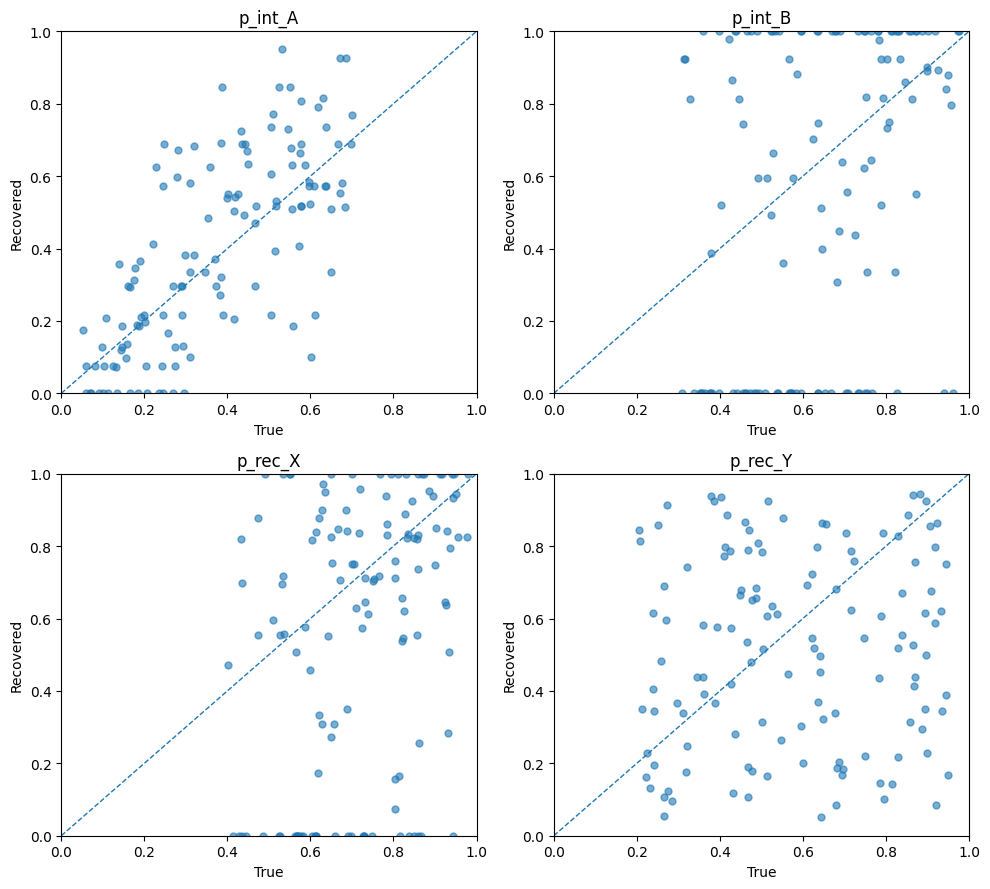

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

pairs = [
    ("true_p_int_A", "est_p_int_A", "p_int_A"),
    ("true_p_int_B", "est_p_int_B", "p_int_B"),
    ("true_p_rec_X", "est_p_rec_X", "p_rec_X"),
    ("true_p_rec_Y", "est_p_rec_Y", "p_rec_Y"),
]

for ax, (tcol, ecol, title) in zip(axes.ravel(), pairs):
    ax.scatter(recovery_df[tcol], recovery_df[ecol], alpha=0.6, s=25)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("True")
    ax.set_ylabel("Recovered")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [49]:
for col in ["est_p_int_A", "est_p_int_B", "est_p_rec_X", "est_p_rec_Y"]:
    print(col)
    print("near 0:", (recovery_df[col] < 0.05).sum())
    print("near 1:", (recovery_df[col] > 0.95).sum())
    print()

est_p_int_A
near 0: 14
near 1: 1

est_p_int_B
near 0: 42
near 1: 41

est_p_rec_X
near 0: 31
near 1: 22

est_p_rec_Y
near 0: 0
near 1: 0



## Interpretation 
Why many estimates near both 0 and 1:
- `p_int_B` and `p_rec_X` are behaving like competing explanations for the same observed data
- The model cannot tell whether good performance on **B-cue** and **X-probe** trials came from:
    - strong proactive intention at cue B, or
	- successful recall at probe X
- the optimizer can often fit the same AX/AY/BX/BY summaries by sending one high and the other low, or vice versa

# 2-parameter No-inhibition Recovery